# 🏁 Box Box Box — Data Exploration

This notebook loads all 30,000 historical race JSON files into two tidy pandas DataFrames:
- **`df_races`** — one row per race (race config + finishing order)
- **`df_stints`** — one row per tire stint per driver per race

Then we explore patterns that will help us reverse-engineer the lap time formula.

## Section 0 — Imports & Config

In [2]:
import json
import glob
import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# ── Paths (relative to repo root) ──────────────────────────────────────────
REPO_ROOT = Path("../")          # notebook lives in solution/
HISTORICAL_DIR = REPO_ROOT / "data" / "historical_races"
TEST_INPUT_DIR  = REPO_ROOT / "data" / "test_cases" / "inputs"
TEST_OUTPUT_DIR = REPO_ROOT / "data" / "test_cases" / "expected_outputs"

# ── Plot style ──────────────────────────────────────────────────────────────
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)

TIRE_COLORS = {"SOFT": "#E8002D", "MEDIUM": "#FFF500", "HARD": "#FFFFFF"}

print("Imports OK")
print(f"Historical race files: {len(list(HISTORICAL_DIR.glob('*.json')))}")

Matplotlib is building the font cache; this may take a moment.


Imports OK
Historical race files: 30


## Section 1 — Load & Flatten JSON → DataFrames

### 1.1  Helper: parse a single race record

In [4]:
def parse_race(race: dict) -> tuple[dict, list[dict]]:
    """
    Given a single race dict, return:
      - race_row  : flat dict for df_races
      - stint_rows: list of flat dicts for df_stints
    """
    cfg = race["race_config"]
    race_id = race["race_id"]
    finishing = race.get("finishing_positions", [])

    # ── Race-level row ──────────────────────────────────────────────────
    race_row = {
        "race_id"       : race_id,
        "track"         : cfg["track"],
        "total_laps"    : cfg["total_laps"],
        "base_lap_time" : cfg["base_lap_time"],
        "pit_lane_time" : cfg["pit_lane_time"],
        "track_temp"    : cfg["track_temp"],
        "finishing_positions": finishing,
    }

    # build a lookup: driver_id → finish position (1-indexed)
    finish_pos_map = {drv: idx + 1 for idx, drv in enumerate(finishing)}

    # ── Stint-level rows ────────────────────────────────────────────────
    stint_rows = []
    total_laps = cfg["total_laps"]

    for pos_key, strategy in race["strategies"].items():
        driver_id   = strategy["driver_id"]
        start_tire  = strategy["starting_tire"]
        pit_stops   = strategy.get("pit_stops", [])
        n_stops     = len(pit_stops)
        grid_pos    = int(pos_key.replace("pos", ""))
        fin_pos     = finish_pos_map.get(driver_id, None)

        # Build stint list from pit stops
        # Each stint: (tire_compound, start_lap, end_lap)
        stints = []
        current_tire = start_tire
        current_start = 1

        for stop in sorted(pit_stops, key=lambda x: x["lap"]):
            pit_lap = stop["lap"]
            stints.append((current_tire, current_start, pit_lap))
            current_tire  = stop["to_tire"]
            current_start = pit_lap + 1

        # Last stint runs to end of race
        stints.append((current_tire, current_start, total_laps))

        for stint_num, (compound, s_start, s_end) in enumerate(stints, start=1):
            stint_rows.append({
                "race_id"          : race_id,
                "track"            : cfg["track"],
                "total_laps"       : total_laps,
                "base_lap_time"    : cfg["base_lap_time"],
                "pit_lane_time"    : cfg["pit_lane_time"],
                "track_temp"       : cfg["track_temp"],
                "driver_id"        : driver_id,
                "starting_grid_pos": grid_pos,
                "finishing_pos"    : fin_pos,
                "num_pitstops"     : n_stops,
                "stint_number"     : stint_num,
                "tire_compound"    : compound,
                "stint_start_lap"  : s_start,
                "stint_end_lap"    : s_end,
                "stint_laps"       : s_end - s_start + 1,
            })

    return race_row, stint_rows

print("Helper defined.")

Helper defined.


### 1.2  Load all 30 historical files → df_races, df_stints

In [5]:
all_race_rows  = []
all_stint_rows = []

files = sorted(HISTORICAL_DIR.glob("*.json"))
print(f"Loading {len(files)} files...")

for fpath in files:
    with open(fpath, "r") as f:
        races = json.load(f)
    for race in races:
        race_row, stint_rows = parse_race(race)
        all_race_rows.append(race_row)
        all_stint_rows.extend(stint_rows)
    print(f"  ✅ {fpath.name}  ({len(races)} races)")

df_races  = pd.DataFrame(all_race_rows)
df_stints = pd.DataFrame(all_stint_rows)

# Enforce dtypes
df_races["total_laps"]     = df_races["total_laps"].astype(int)
df_races["track_temp"]     = df_races["track_temp"].astype(int)
df_stints["finishing_pos"] = df_stints["finishing_pos"].astype("Int64")
df_stints["tire_compound"] = pd.Categorical(
    df_stints["tire_compound"], categories=["SOFT", "MEDIUM", "HARD"], ordered=True
)

print(f"\n✅ Done!")
print(f"df_races  shape : {df_races.shape}")
print(f"df_stints shape : {df_stints.shape}")

Loading 30 files...
  ✅ races_00000-00999.json  (1000 races)
  ✅ races_01000-01999.json  (1000 races)
  ✅ races_02000-02999.json  (1000 races)
  ✅ races_03000-03999.json  (1000 races)
  ✅ races_04000-04999.json  (1000 races)
  ✅ races_05000-05999.json  (1000 races)
  ✅ races_06000-06999.json  (1000 races)
  ✅ races_07000-07999.json  (1000 races)
  ✅ races_08000-08999.json  (1000 races)
  ✅ races_09000-09999.json  (1000 races)
  ✅ races_10000-10999.json  (1000 races)
  ✅ races_11000-11999.json  (1000 races)
  ✅ races_12000-12999.json  (1000 races)
  ✅ races_13000-13999.json  (1000 races)
  ✅ races_14000-14999.json  (1000 races)
  ✅ races_15000-15999.json  (1000 races)
  ✅ races_16000-16999.json  (1000 races)
  ✅ races_17000-17999.json  (1000 races)
  ✅ races_18000-18999.json  (1000 races)
  ✅ races_19000-19999.json  (1000 races)
  ✅ races_20000-20999.json  (1000 races)
  ✅ races_21000-21999.json  (1000 races)
  ✅ races_22000-22999.json  (1000 races)
  ✅ races_23000-23999.json  (1000 rac

### 1.3  Quick peek at the DataFrames

In [6]:
print("=== df_races ===")
display(df_races.drop(columns=["finishing_positions"]).head(5))
print("\nColumn dtypes:")
display(df_races.dtypes)

=== df_races ===


,race_id,track,total_laps,base_lap_time,pit_lane_time,track_temp
0,R21072,Suzuka,50,84.5,22.7,27
1,R05618,Suzuka,40,86.7,20.6,30
2,R11409,Monza,36,82.9,21.3,33
3,R20073,Silverstone,52,90.6,21.6,28
4,R13543,COTA,44,80.5,21.0,34



Column dtypes:


race_id                    str
track                      str
total_laps               int64
base_lap_time          float64
pit_lane_time          float64
track_temp               int64
finishing_positions     object
dtype: object

In [7]:
print("=== df_stints ===")
display(df_stints.head(10))
print("\nColumn dtypes:")
display(df_stints.dtypes)

=== df_stints ===


,race_id,track,total_laps,base_lap_time,pit_lane_time,track_temp,driver_id,starting_grid_pos,finishing_pos,num_pitstops,stint_number,tire_compound,stint_start_lap,stint_end_lap,stint_laps
0,R21072,Suzuka,50,84.5,22.7,27,D001,1,1,1,1,MEDIUM,1,23,23
1,R21072,Suzuka,50,84.5,22.7,27,D001,1,1,1,2,HARD,24,50,27
2,R21072,Suzuka,50,84.5,22.7,27,D002,2,4,2,1,MEDIUM,1,12,12
3,R21072,Suzuka,50,84.5,22.7,27,D002,2,4,2,2,HARD,13,29,17
4,R21072,Suzuka,50,84.5,22.7,27,D002,2,4,2,3,MEDIUM,30,50,21
5,R21072,Suzuka,50,84.5,22.7,27,D003,3,13,1,1,SOFT,1,15,15
6,R21072,Suzuka,50,84.5,22.7,27,D003,3,13,1,2,MEDIUM,16,50,35
7,R21072,Suzuka,50,84.5,22.7,27,D004,4,6,2,1,MEDIUM,1,12,12
8,R21072,Suzuka,50,84.5,22.7,27,D004,4,6,2,2,HARD,13,33,21
9,R21072,Suzuka,50,84.5,22.7,27,D004,4,6,2,3,MEDIUM,34,50,17



Column dtypes:


race_id                   str
track                     str
total_laps              int64
base_lap_time         float64
pit_lane_time         float64
track_temp              int64
driver_id                 str
starting_grid_pos       int64
finishing_pos           Int64
num_pitstops            int64
stint_number            int64
tire_compound        category
stint_start_lap         int64
stint_end_lap           int64
stint_laps              int64
dtype: object

---
## Section 2 — Summary Statistics

### 2.1  Race config overview

In [8]:
print("=== df_races descriptive stats ===")
display(df_races[["total_laps", "base_lap_time", "pit_lane_time", "track_temp"]].describe().round(2))

=== df_races descriptive stats ===


,total_laps,base_lap_time,pit_lane_time,track_temp
count,30000.00,30000.00,30000.00,30000.00
mean,45.52,87.50,22.00,30.31
std,10.37,4.34,1.16,4.58
min,25.00,80.00,20.00,18.00
25%,38.00,83.70,21.00,28.00
50%,45.00,87.50,22.00,30.00
75%,52.00,91.30,23.00,33.00
max,70.00,95.00,24.00,42.00


### 2.2  Races per track

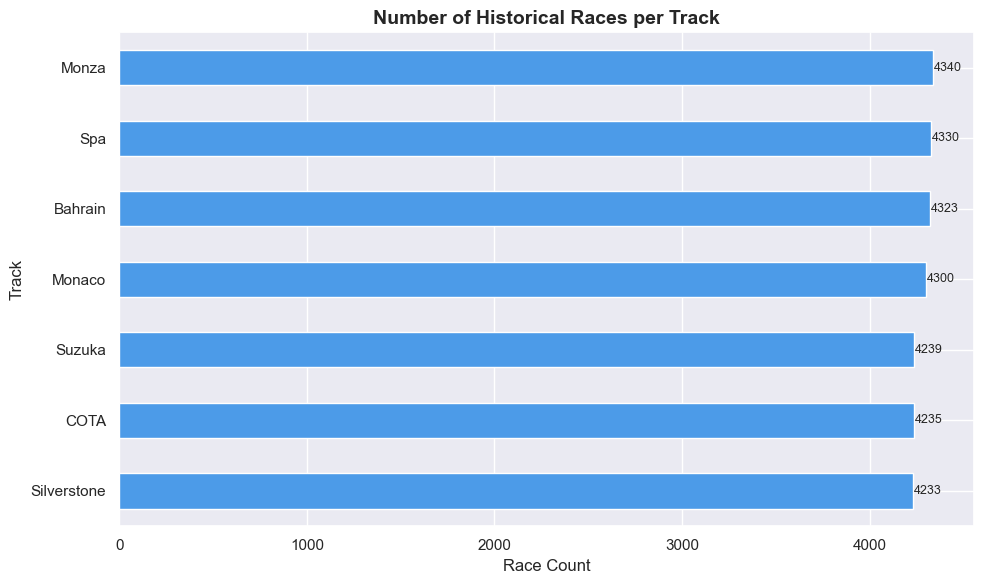

track
Silverstone    4233
COTA           4235
Suzuka         4239
Monaco         4300
Bahrain        4323
Spa            4330
Monza          4340


In [9]:
track_counts = df_races["track"].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
track_counts.plot(kind="barh", ax=ax, color="#4C9BE8")
ax.set_title("Number of Historical Races per Track", fontsize=14, fontweight="bold")
ax.set_xlabel("Race Count")
ax.set_ylabel("Track")
for bar in ax.patches:
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            f"{int(bar.get_width())}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

print(track_counts.to_string())

### 2.3  Track temperature distribution

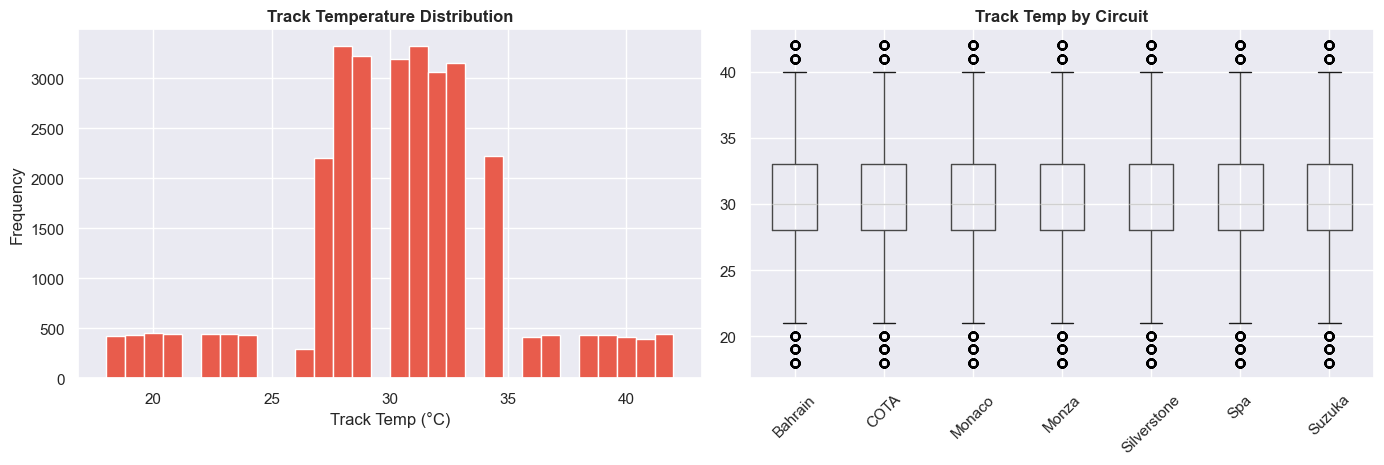

              count  mean  std   min   25%   50%   75%   max
track                                                       
Bahrain      4323.0  30.3  4.6  18.0  28.0  30.0  33.0  42.0
COTA         4235.0  30.3  4.6  18.0  28.0  30.0  33.0  42.0
Monaco       4300.0  30.4  4.6  18.0  28.0  30.0  33.0  42.0
Monza        4340.0  30.2  4.5  18.0  28.0  30.0  33.0  42.0
Silverstone  4233.0  30.4  4.6  18.0  28.0  30.0  33.0  42.0
Spa          4330.0  30.3  4.6  18.0  28.0  30.0  33.0  42.0
Suzuka       4239.0  30.3  4.5  18.0  28.0  30.0  33.0  42.0


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
df_races["track_temp"].plot(kind="hist", bins=30, ax=axes[0], color="#E85C4C", edgecolor="white")
axes[0].set_title("Track Temperature Distribution", fontweight="bold")
axes[0].set_xlabel("Track Temp (°C)")

# Per-track box plot
df_races.boxplot(column="track_temp", by="track", ax=axes[1], rot=45)
axes[1].set_title("Track Temp by Circuit", fontweight="bold")
axes[1].set_xlabel("")
plt.suptitle("")
plt.tight_layout()
plt.show()

print(df_races.groupby("track")["track_temp"].describe().round(1))

### 2.4  Pit stop count distribution

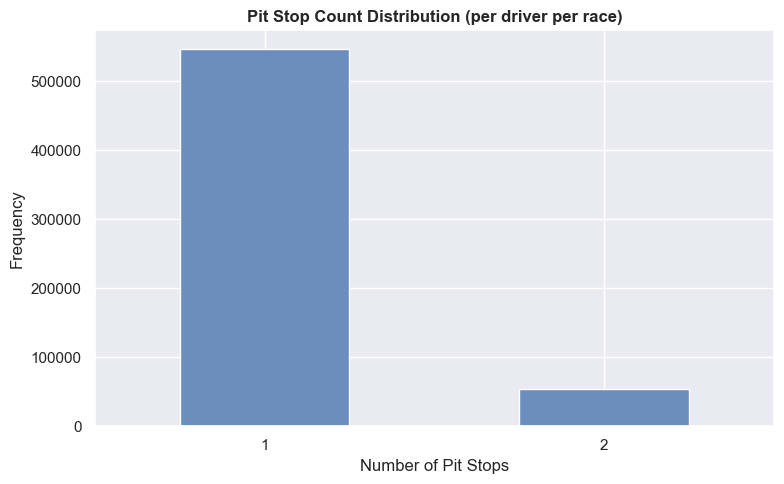

num_pitstops
1    546021
2     53979


In [11]:
# Unique stops per driver per race
stop_dist = df_stints.groupby(["race_id", "driver_id"])["num_pitstops"].first()

fig, ax = plt.subplots(figsize=(8, 5))
stop_dist.value_counts().sort_index().plot(kind="bar", ax=ax, color="#6C8EBF", edgecolor="white")
ax.set_title("Pit Stop Count Distribution (per driver per race)", fontweight="bold")
ax.set_xlabel("Number of Pit Stops")
ax.set_ylabel("Frequency")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

print(stop_dist.value_counts().sort_index().to_string())

### 2.5  Tire compound usage

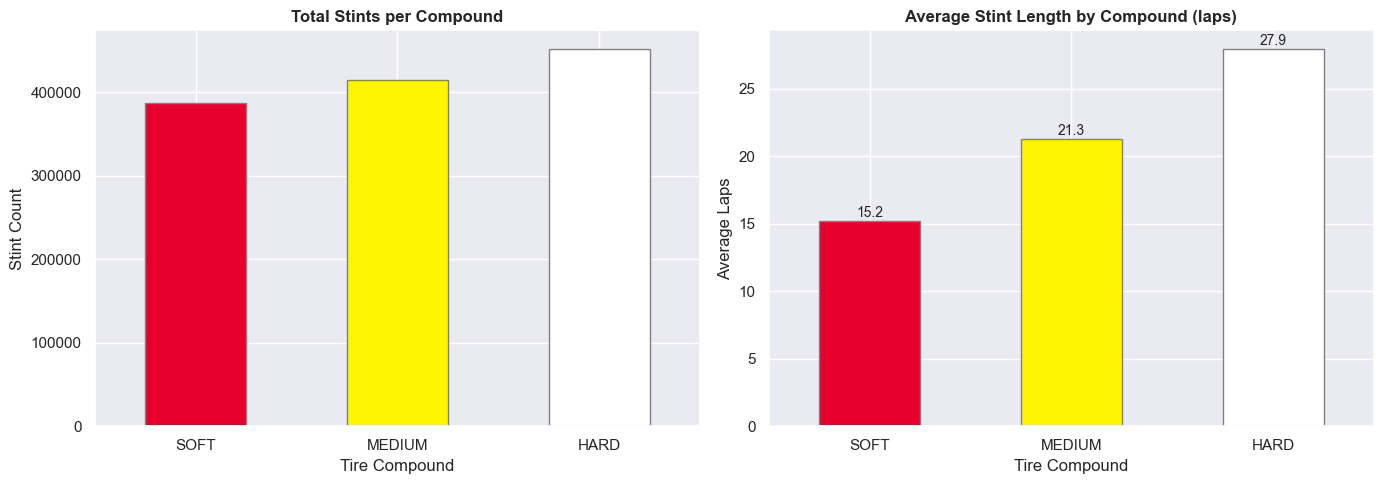

Avg stint lengths:
tire_compound
SOFT      15.16
MEDIUM    21.28
HARD      27.91


In [12]:
compound_counts = df_stints["tire_compound"].value_counts().sort_index()
colors = [TIRE_COLORS[c] for c in compound_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count of stints
compound_counts.plot(kind="bar", ax=axes[0], color=colors, edgecolor="gray")
axes[0].set_title("Total Stints per Compound", fontweight="bold")
axes[0].set_xlabel("Tire Compound")
axes[0].set_ylabel("Stint Count")
axes[0].tick_params(axis="x", rotation=0)

# Average stint length
avg_stint = df_stints.groupby("tire_compound", observed=True)["stint_laps"].mean()
avg_stint.plot(kind="bar", ax=axes[1], color=colors, edgecolor="gray")
axes[1].set_title("Average Stint Length by Compound (laps)", fontweight="bold")
axes[1].set_xlabel("Tire Compound")
axes[1].set_ylabel("Average Laps")
axes[1].tick_params(axis="x", rotation=0)
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f"{bar.get_height():.1f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

print("Avg stint lengths:")
print(avg_stint.round(2).to_string())

### 2.6  Stint length distribution per compound (box plot)

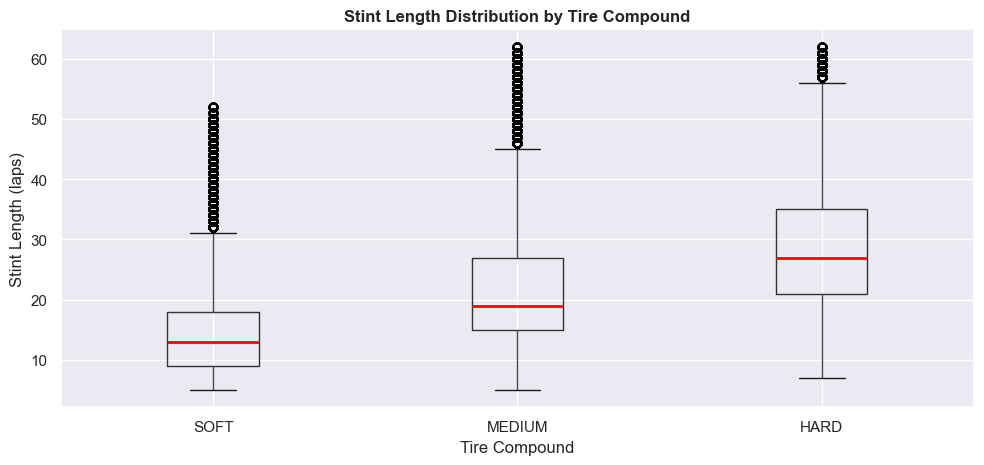

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
df_stints.boxplot(column="stint_laps", by="tire_compound", ax=ax,
                  boxprops=dict(color="#333"),
                  medianprops=dict(color="red", linewidth=2))
ax.set_title("Stint Length Distribution by Tire Compound", fontweight="bold")
ax.set_xlabel("Tire Compound")
ax.set_ylabel("Stint Length (laps)")
plt.suptitle("")
plt.tight_layout()
plt.show()

### 2.7  Starting tire compound vs. finishing position

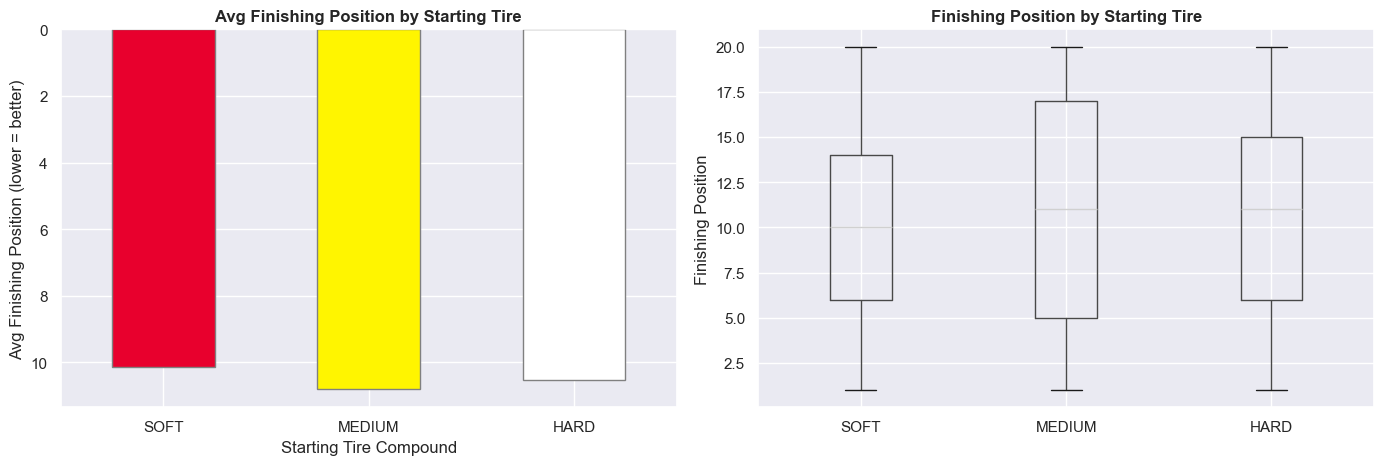

tire_compound
SOFT      10.13
MEDIUM    10.81
HARD      10.54


In [14]:
# Only look at stint_number == 1 (starting tire = first stint)
starting_stints = df_stints[df_stints["stint_number"] == 1].copy()

avg_fin = starting_stints.groupby("tire_compound", observed=True)["finishing_pos"].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average finishing position
colors = [TIRE_COLORS[c] for c in avg_fin.index]
avg_fin.plot(kind="bar", ax=axes[0], color=colors, edgecolor="gray")
axes[0].set_title("Avg Finishing Position by Starting Tire", fontweight="bold")
axes[0].set_xlabel("Starting Tire Compound")
axes[0].set_ylabel("Avg Finishing Position (lower = better)")
axes[0].invert_yaxis()
axes[0].tick_params(axis="x", rotation=0)

# Box plot
starting_stints.boxplot(column="finishing_pos", by="tire_compound", ax=axes[1])
axes[1].set_title("Finishing Position by Starting Tire", fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("Finishing Position")
plt.suptitle("")
plt.tight_layout()
plt.show()

print(avg_fin.round(2).to_string())

### 2.8  Number of pit stops vs. finishing position

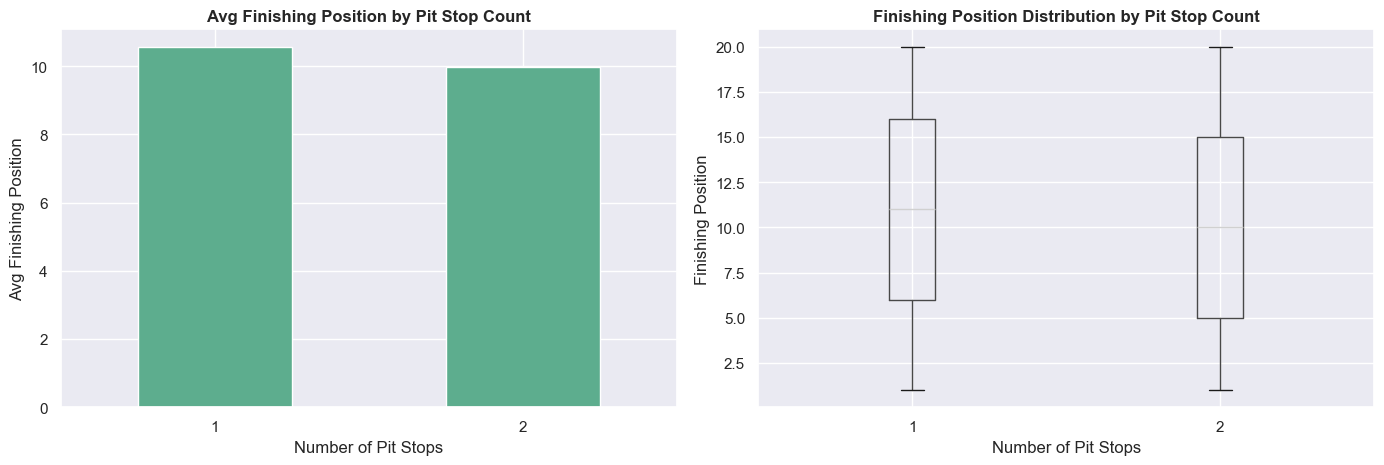

num_pitstops
1    10.55
2     9.97


In [15]:
driver_level = df_stints.groupby(["race_id", "driver_id"], observed=True).agg(
    finishing_pos=("finishing_pos", "first"),
    num_pitstops=("num_pitstops", "first"),
    track=("track", "first"),
).reset_index()

avg_by_stops = driver_level.groupby("num_pitstops")["finishing_pos"].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

avg_by_stops.plot(kind="bar", ax=axes[0], color="#5DAD8E", edgecolor="white")
axes[0].set_title("Avg Finishing Position by Pit Stop Count", fontweight="bold")
axes[0].set_xlabel("Number of Pit Stops")
axes[0].set_ylabel("Avg Finishing Position")
axes[0].tick_params(axis="x", rotation=0)

driver_level.boxplot(column="finishing_pos", by="num_pitstops", ax=axes[1])
axes[1].set_title("Finishing Position Distribution by Pit Stop Count", fontweight="bold")
axes[1].set_xlabel("Number of Pit Stops")
axes[1].set_ylabel("Finishing Position")
plt.suptitle("")
plt.tight_layout()
plt.show()

print(avg_by_stops.round(2).to_string())

### 2.9  Track temperature vs. pit stop count (does hot weather encourage more stops?)

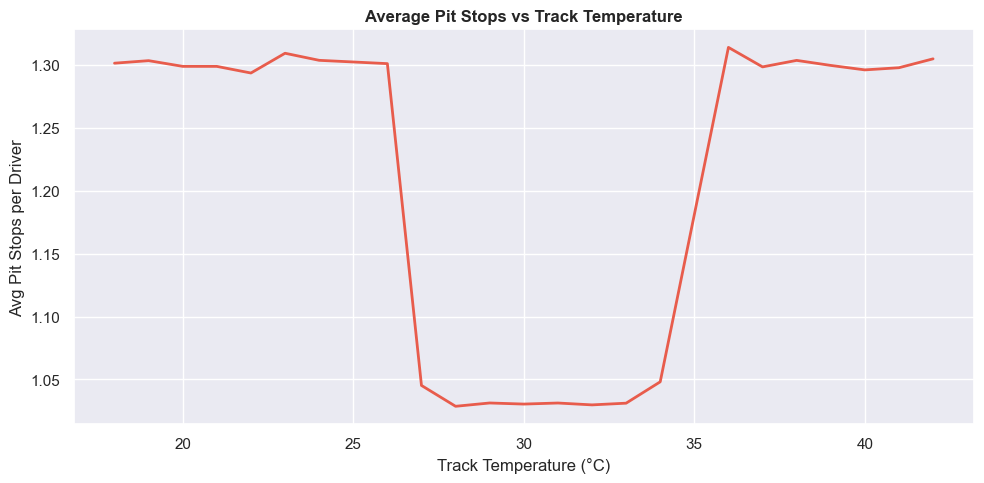

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
driver_level2 = df_stints.drop_duplicates(["race_id", "driver_id"]) \
    [["race_id", "driver_id", "track_temp", "num_pitstops"]]

avg_stops_by_temp = driver_level2.groupby("track_temp")["num_pitstops"].mean()
avg_stops_by_temp.plot(ax=ax, color="#E85C4C", linewidth=2)
ax.set_title("Average Pit Stops vs Track Temperature", fontweight="bold")
ax.set_xlabel("Track Temperature (°C)")
ax.set_ylabel("Avg Pit Stops per Driver")
plt.tight_layout()
plt.show()

---
## Section 3 — Sanity Checks

In [17]:
errors = []

# 1. Total races
assert len(df_races) == 30_000, f"Expected 30000 races, got {len(df_races)}"
print(f"✅ Total races          : {len(df_races):,}")

# 2. All races have exactly 20 drivers
driver_counts = df_stints.groupby("race_id")["driver_id"].nunique()
bad = driver_counts[driver_counts != 20]
assert len(bad) == 0, f"Races with != 20 drivers: {bad}"
print(f"✅ All races have 20 drivers")

# 3. Finishing positions always 20 entries
fin_len = df_races["finishing_positions"].map(len)
bad_fin = fin_len[fin_len != 20]
assert len(bad_fin) == 0, f"Races with wrong finishing_positions length: {bad_fin}"
print(f"✅ All finishing_positions have 20 entries")

# 4. Tire compounds only SOFT / MEDIUM / HARD
assert df_stints["tire_compound"].isin(["SOFT", "MEDIUM", "HARD"]).all()
print(f"✅ Tire compounds valid  : {df_stints['tire_compound'].unique().tolist()}")

# 5. No nulls in key columns
key_cols = ["race_id", "driver_id", "tire_compound", "stint_laps", "finishing_pos"]
nulls = df_stints[key_cols].isnull().sum()
assert nulls.sum() == 0, f"Null values found:\n{nulls[nulls > 0]}"
print(f"✅ No nulls in key stint columns")

# 6. Stint laps always positive
assert (df_stints["stint_laps"] > 0).all()
print(f"✅ All stints have positive lap count")

# 7. Unique race IDs
assert df_races["race_id"].is_unique, "Duplicate race IDs found!"
print(f"✅ All race IDs are unique")

print("\n🏁 All sanity checks passed!")

✅ Total races          : 30,000
✅ All races have 20 drivers
✅ All finishing_positions have 20 entries
✅ Tire compounds valid  : ['MEDIUM', 'HARD', 'SOFT']
✅ No nulls in key stint columns
✅ All stints have positive lap count
✅ All race IDs are unique

🏁 All sanity checks passed!


---
## Section 4 — Load Test Cases

In [18]:
test_stint_rows = []
test_race_rows  = []

for fpath in sorted(TEST_INPUT_DIR.glob("*.json")):
    with open(fpath) as f:
        race = json.load(f)
    
    # Load expected output to get finishing positions
    out_file = TEST_OUTPUT_DIR / fpath.name
    if out_file.exists():
        with open(out_file) as f:
            out = json.load(f)
        race["finishing_positions"] = out["finishing_positions"]
    else:
        race["finishing_positions"] = []

    r, s = parse_race(race)
    test_race_rows.append(r)
    test_stint_rows.extend(s)

df_test_races  = pd.DataFrame(test_race_rows)
df_test_stints = pd.DataFrame(test_stint_rows)

print(f"Test races  : {len(df_test_races)}")
print(f"Test stints : {len(df_test_stints)}")
display(df_test_races.drop(columns=["finishing_positions"]).head())

Test races  : 100
Test stints : 4174


,race_id,track,total_laps,base_lap_time,pit_lane_time,track_temp
0,TEST_001,Monaco,31,84.3,21.4,32
1,TEST_002,Monaco,34,92.1,21.1,30
2,TEST_003,Suzuka,44,90.2,20.3,32
3,TEST_004,Bahrain,36,84.7,23.2,29
4,TEST_005,Silverstone,47,87.6,22.1,31


---
## Section 5 — Save DataFrames as Parquet (for fast reloading)

In [ ]:
SAVE_DIR = Path("../data/processed")
SAVE_DIR.mkdir(exist_ok=True)

# Save without the list column (not parquet-friendly)
df_races.drop(columns=["finishing_positions"]).to_parquet(SAVE_DIR / "races.parquet", index=False)
df_stints.to_parquet(SAVE_DIR / "stints.parquet", index=False)
df_test_races.drop(columns=["finishing_positions"]).to_parquet(SAVE_DIR / "test_races.parquet", index=False)
df_test_stints.to_parquet(SAVE_DIR / "test_stints.parquet", index=False)

print("✅ Saved to data/processed/:")
for f in sorted(SAVE_DIR.glob("*.parquet")):
    print(f"   {f.name}  ({f.stat().st_size / 1024 / 1024:.1f} MB)")

---
## 🎯 Key Observations (fill in after running)

Use this section to note patterns you discover:

- **Tire compound speed**: SOFT seems fastest but ... 
- **Tire degradation**: Stints of different lengths show ...
- **Temperature effect**: Higher temps seem to ...
- **Pit stop strategy**: Most drivers do ... stops
- **Hypothesis for formula**: ...